In [100]:
from datetime import datetime

import numpy as np
import pandas as pd

from energymanagementrl.pv_prod_simulation.main import run_energy_production_prediction, analyze_production, WeatherType
from energymanagementrl.pv_prod_simulation.simulation import PanelModel, ArrayConfig, PlantConfig

In [5]:
from dotenv import load_dotenv
import os

load_dotenv()
LAT = float(os.environ.get("LAT"))
LON = float(os.environ.get("LON"))

In [54]:
start = datetime.strptime('2021-04-10', '%Y-%m-%d')
end = datetime.strptime('2024-12-14', '%Y-%m-%d')

In [154]:
panel_model = PanelModel(pdc0=0.42, temp_model_a=-3.56, temp_model_b=-0.075, delta_t=3, gamma_pdc=-0.004)
arrays = [ArrayConfig(name='sud_east', panel_model=panel_model, num_panels=14, tilt_angle=25, azimuth=110),
          ArrayConfig(name='nord_west', panel_model=panel_model, num_panels=14, tilt_angle=18, azimuth=290)]

plant_config = PlantConfig(
    latitude=LAT, longitude=LON, timezone='Europe/Rome', inverter_pdc0=6, arrays=arrays
)

Coordinates: 37.5625°N, 15.0°E
Elevation: 541.0 m asl
Timezone: b'Europe/Rome' b'CET'
Total AC energy: 177633.62 kWh
Max production: 5.76 kW at 2021-04-10 07:30:00
Production starts at: 2021-04-10 04:35:00, ends at: 2024-12-14 15:40:00


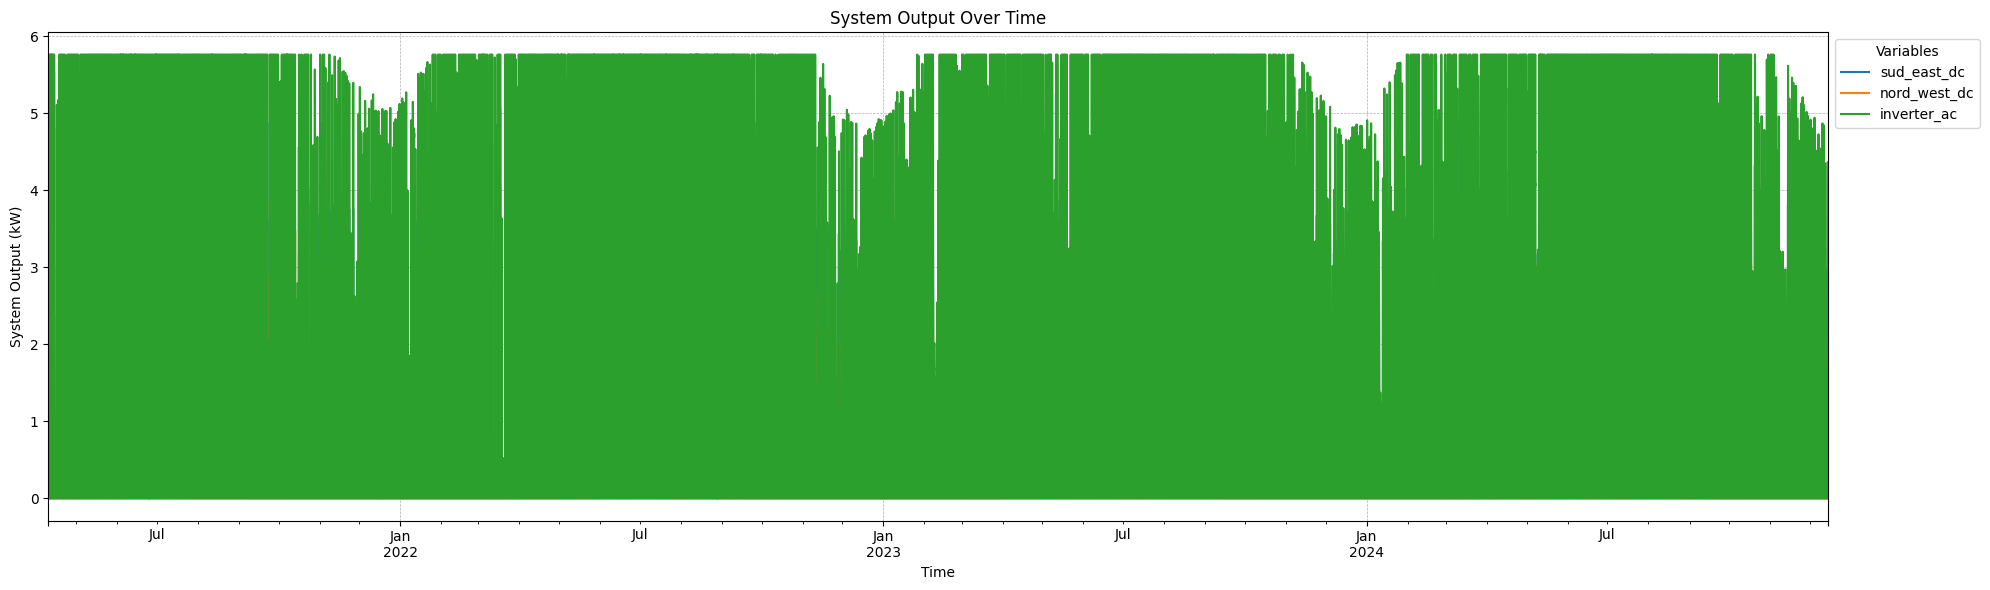

(np.float64(5.76),
 Timestamp('2021-04-10 07:30:00'),
 Timestamp('2021-04-10 04:35:00'),
 Timestamp('2024-12-14 15:40:00'))

In [155]:
open_meteo_production_df = run_energy_production_prediction(
    plant_config,
    start.strftime('%Y-%m-%d %H:%M'),
    end.strftime('%Y-%m-%d %H:%M'),
    WeatherType.open_meteo
)
open_meteo_production_df = open_meteo_production_df.tz_convert('UTC').tz_localize(None)
open_meteo_production_df = open_meteo_production_df.resample('5min').interpolate(method='linear')
analyze_production(open_meteo_production_df)

Total AC energy: 189196.21 kWh
Max production: 5.76 kW at 2021-04-10 08:00:00
Production starts at: 2021-04-10 04:50:00, ends at: 2024-12-13 15:40:00


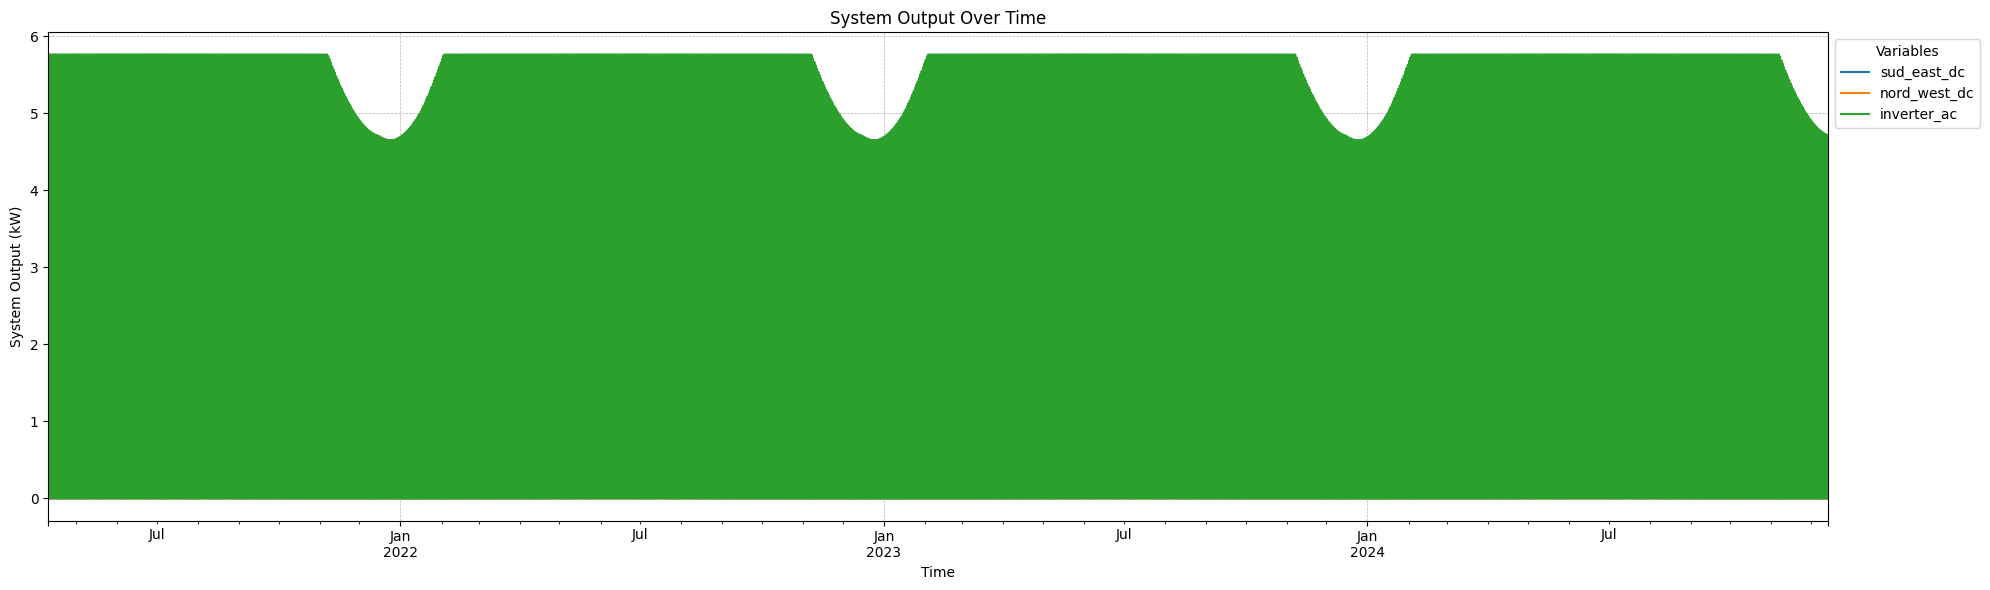

(np.float64(5.76),
 Timestamp('2021-04-10 08:00:00'),
 Timestamp('2021-04-10 04:50:00'),
 Timestamp('2024-12-13 15:40:00'))

In [156]:
clear_sky_production_df = run_energy_production_prediction(
    plant_config,
    start.strftime('%Y-%m-%d %H:%M'),
    end.strftime('%Y-%m-%d %H:%M'),
)
clear_sky_production_df.index = clear_sky_production_df.index.tz_localize(None)
clear_sky_production_df = clear_sky_production_df.resample('5min').interpolate(method='linear')
analyze_production(clear_sky_production_df)

In [110]:
clear_sky_production_df.rename({'inverter_ac': 'production_power_kw_optimal'}, axis=1, inplace=True)
open_meteo_production_df.rename({'inverter_ac': 'production_power_kw_weather_dependent'}, axis=1, inplace=True)
df_0 = pd.concat([clear_sky_production_df.production_optimal_kw,
                  open_meteo_production_df.production_weather_dependent_kw], axis=1)

<Axes: >

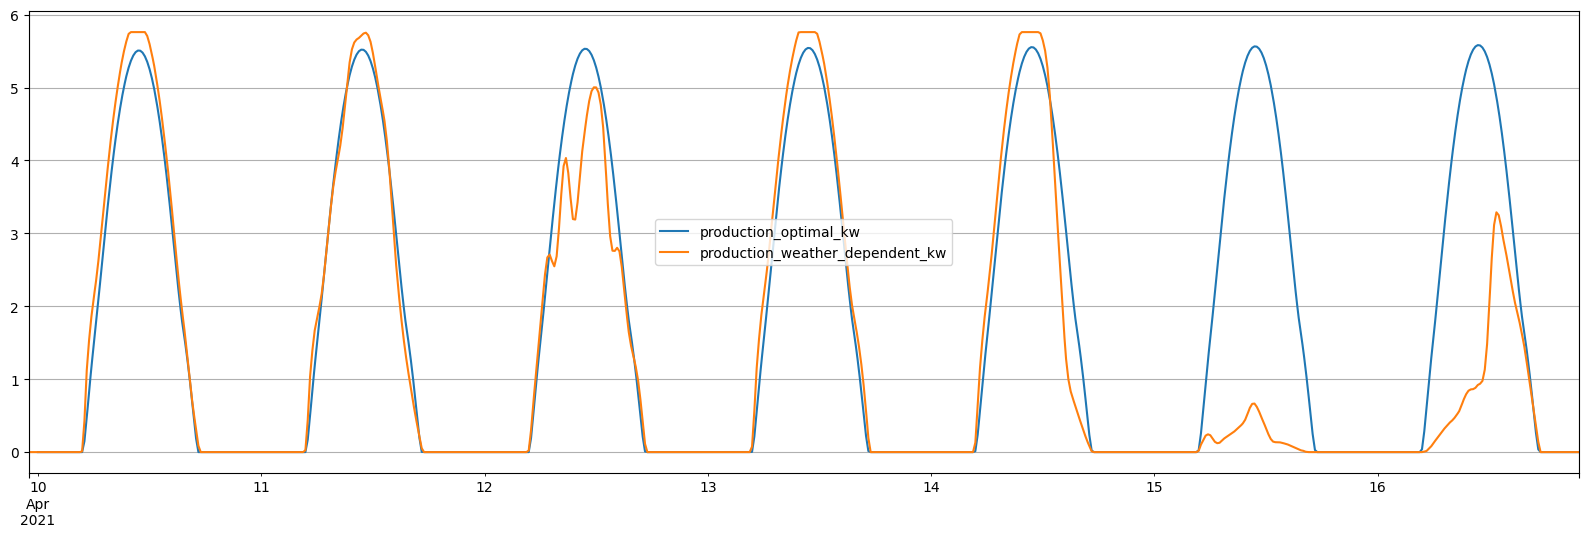

In [157]:
df_0[:2000].plot(figsize=(20, 6), grid=True)

In [170]:
df_1 = pd.read_csv('../data/plant_hist.csv', parse_dates=['timestamp'], index_col='timestamp')
df_1 = df_1[~df_1.index.duplicated(keep='first')]

In [171]:
df = pd.concat([df_0, df_1], axis=1)
df = df[df.index >= pd.to_datetime('2024-04-01')]
df = df[df.index < pd.to_datetime('2024-12-14')]
df.ffill(inplace=True)
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 74016 entries, 2024-04-01 00:00:00 to 2024-12-13 23:55:00
Freq: 5min
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   production_optimal_kw            74016 non-null  float64
 1   production_weather_dependent_kw  74016 non-null  float64
 2   production_power_kw              74016 non-null  float64
 3   load_power_kw                    74016 non-null  float64
 4   grid_power_kw                    74016 non-null  float64
 5   stored_power_kw                  74016 non-null  float64
 6   SOC                              74016 non-null  float64
dtypes: float64(7)
memory usage: 4.5 MB


In [172]:
df_2 = pd.read_csv('../data/complete_series.ex.csv', parse_dates=['index'], index_col='index')
df = pd.concat([df, df_2.grid_voltage], axis=1).dropna()
df

,production_optimal_kw,production_weather_dependent_kw,production_power_kw,load_power_kw,grid_power_kw,stored_power_kw,SOC,grid_voltage
2024-04-01 00:00:00,0.0,0.0,0.0,-0.342,0.00000,0.342,73.0,237.4
2024-04-01 00:05:00,0.0,0.0,0.0,-0.346,-0.01001,0.336,73.0,236.5
2024-04-01 00:10:00,0.0,0.0,0.0,-0.336,0.00000,0.336,73.0,237.0
2024-04-01 00:15:00,0.0,0.0,0.0,-0.336,0.00000,0.336,73.0,235.8
2024-04-01 00:20:00,0.0,0.0,0.0,-0.335,0.00000,0.335,72.0,236.1
...,...,...,...,...,...,...,...,...
2024-12-13 23:35:00,0.0,0.0,0.0,-0.280,-0.28000,0.000,10.0,228.9
2024-12-13 23:40:00,0.0,0.0,0.0,-0.350,-0.35000,0.000,10.0,226.0
2024-12-13 23:45:00,0.0,0.0,0.0,-0.350,-0.35000,0.000,10.0,226.5
2024-12-13 23:50:00,0.0,0.0,0.0,-0.350,-0.35000,0.000,10.0,225.7


In [173]:
df.to_csv('../data/complete_series.ex.12kw.csv',index_label='index')

In [174]:
pd.read_csv('../data/complete_series.ex.12kw.csv',parse_dates=['index'], index_col='index' ).info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 74016 entries, 2024-04-01 00:00:00 to 2024-12-13 23:55:00
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   production_optimal_kw            74016 non-null  float64
 1   production_weather_dependent_kw  74016 non-null  float64
 2   production_power_kw              74016 non-null  float64
 3   load_power_kw                    74016 non-null  float64
 4   grid_power_kw                    74016 non-null  float64
 5   stored_power_kw                  74016 non-null  float64
 6   SOC                              74016 non-null  float64
 7   grid_voltage                     74016 non-null  float64
dtypes: float64(8)
memory usage: 5.1 MB


In [152]:
0.42*9*2

7.56